<a href="https://colab.research.google.com/github/elshaymaAnalyst/PythonProject/blob/main/FullEndToEnd_DataScienceipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd


In [2]:
df=pd.read_csv('/content/loan-data - Processed - loan-data - Processed.csv')

In [3]:
df.head(2)

,customer_id,disbursed_amount,interest,market,employment,time_employed,householder,income,date_issued,target,loan_purpose,number_open_accounts,date_last_payment,number_credit_lines_12
0,0,23201.5,15.4840,C,Teacher,<=5 years,RENT,84600.0,2013-06-11,0,Debt consolidation,4,2016-01-14,NaN
1,1,7425.0,11.2032,B,Accountant,<=5 years,OWNER,102000.0,2014-05-08,0,Car purchase,13,2016-01-25,NaN


In [4]:
# Null values

In [5]:
df.isnull().sum()

,0
customer_id,0
disbursed_amount,17
interest,19
market,0
employment,611
time_employed,529
householder,0
income,0
date_issued,0
target,0


In [6]:
import missingno as msno

<Axes: >

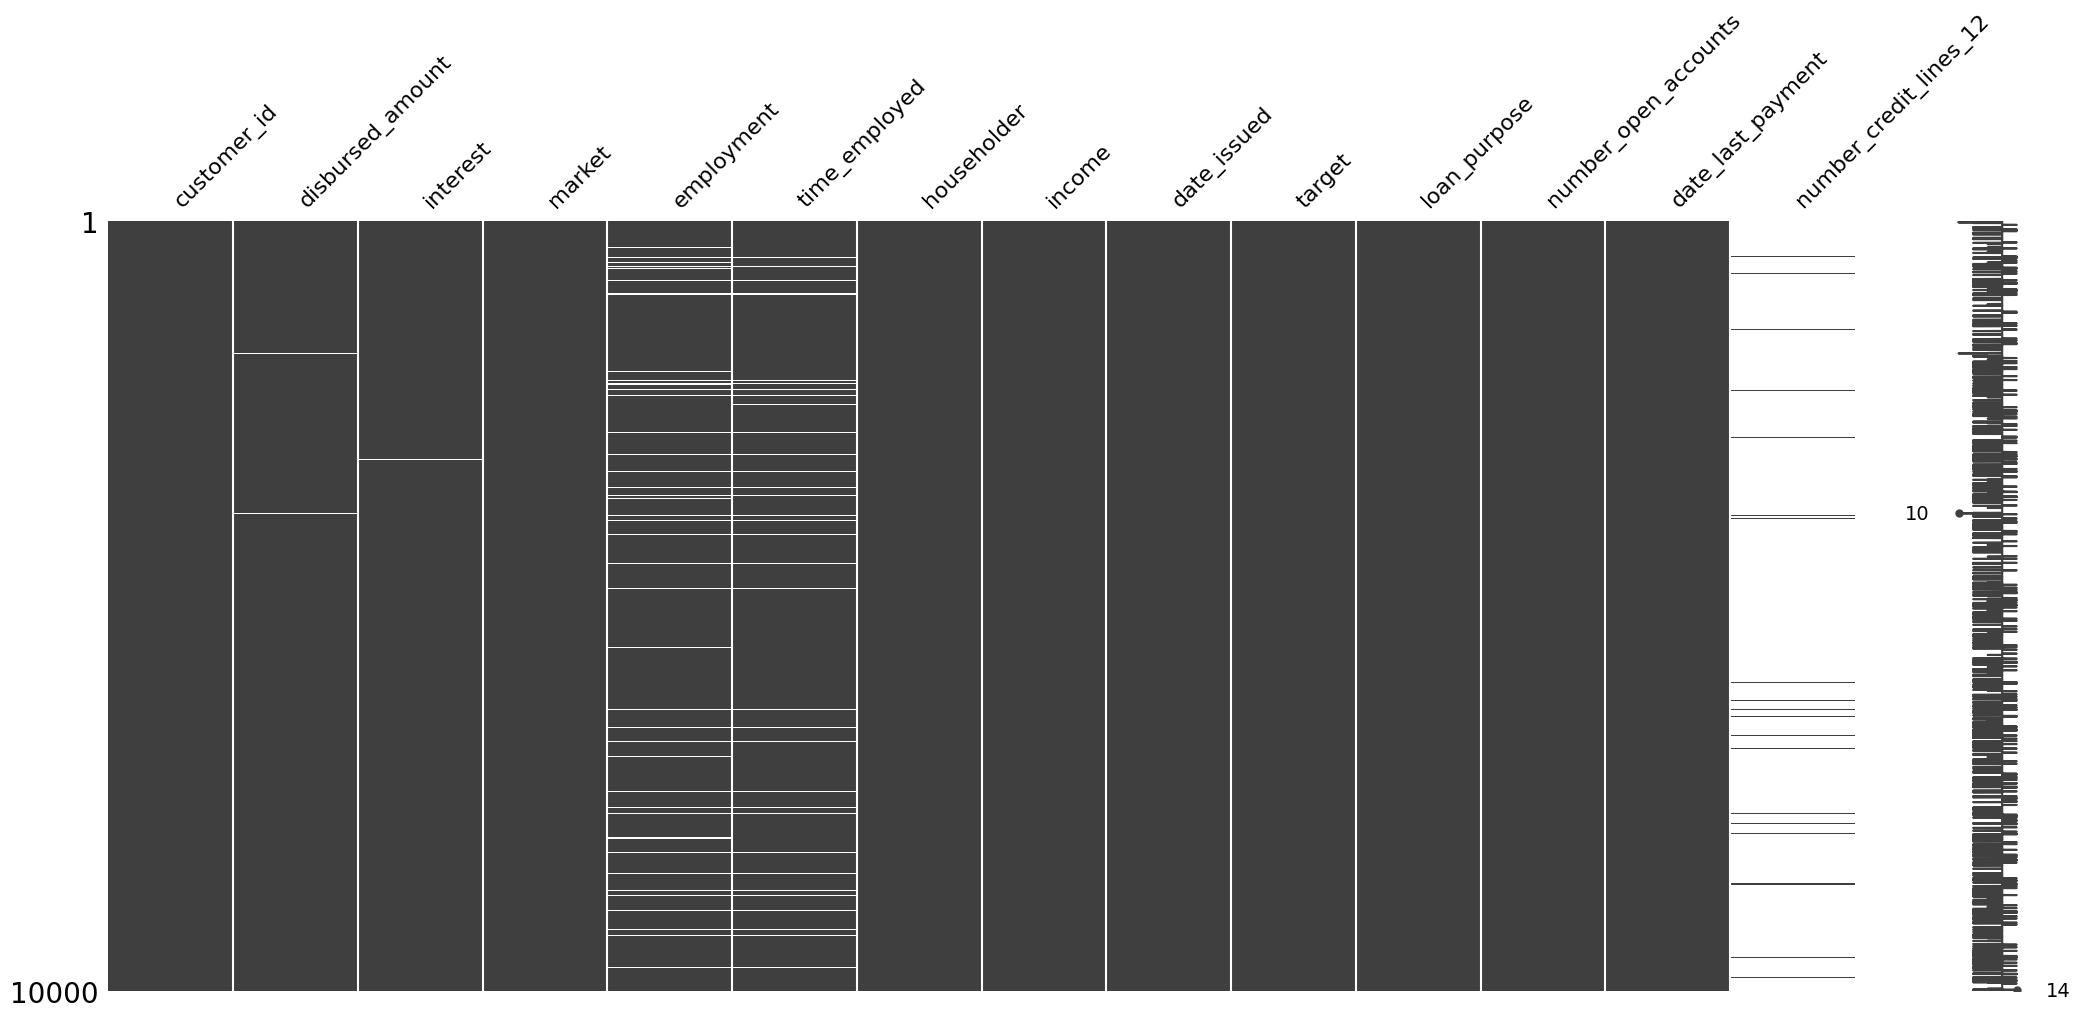

In [7]:
msno.matrix(df)

In [8]:
from sklearn.impute import KNNImputer

In [9]:
knni=KNNImputer()

In [10]:
knni.fit(df[['disbursed_amount']])

KNNImputer()

In [11]:
df['disbursed_amount']=knni.transform(df[['disbursed_amount']])

In [12]:
df.isnull().sum()

,0
customer_id,0
disbursed_amount,0
interest,19
market,0
employment,611
time_employed,529
householder,0
income,0
date_issued,0
target,0


In [13]:
knni.fit(df[['interest']])
df['interest']=knni.transform(df[['interest']])

In [14]:
df.isnull().sum()

,0
customer_id,0
disbursed_amount,0
interest,0
market,0
employment,611
time_employed,529
householder,0
income,0
date_issued,0
target,0


In [15]:
df=df.drop('number_credit_lines_12',axis='columns')

In [16]:
df.columns

Index(['customer_id', 'disbursed_amount', 'interest', 'market', 'employment',
       'time_employed', 'householder', 'income', 'date_issued', 'target',
       'loan_purpose', 'number_open_accounts', 'date_last_payment'],
      dtype='object')

In [17]:
df=df.drop('customer_id',axis='columns')

In [18]:
df.isnull().sum()

,0
disbursed_amount,0
interest,0
market,0
employment,611
time_employed,529
householder,0
income,0
date_issued,0
target,0
loan_purpose,0


In [19]:
df.shape

(10000, 12)

In [20]:
df=df.dropna()

In [21]:
df.shape

(9384, 12)

In [22]:
df.isnull().sum()

,0
disbursed_amount,0
interest,0
market,0
employment,0
time_employed,0
householder,0
income,0
date_issued,0
target,0
loan_purpose,0


In [23]:
df.head(2)

,disbursed_amount,interest,market,employment,time_employed,householder,income,date_issued,target,loan_purpose,number_open_accounts,date_last_payment
0,23201.5,15.4840,C,Teacher,<=5 years,RENT,84600.0,2013-06-11,0,Debt consolidation,4,2016-01-14
1,7425.0,11.2032,B,Accountant,<=5 years,OWNER,102000.0,2014-05-08,0,Car purchase,13,2016-01-25


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9384 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   disbursed_amount      9384 non-null   float64
 1   interest              9384 non-null   float64
 2   market                9384 non-null   object 
 3   employment            9384 non-null   object 
 4   time_employed         9384 non-null   object 
 5   householder           9384 non-null   object 
 6   income                9384 non-null   float64
 7   date_issued           9384 non-null   object 
 8   target                9384 non-null   int64  
 9   loan_purpose          9384 non-null   object 
 10  number_open_accounts  9384 non-null   int64  
 11  date_last_payment     9384 non-null   object 
dtypes: float64(3), int64(2), object(7)
memory usage: 1.2+ MB


In [25]:
df.columns

Index(['disbursed_amount', 'interest', 'market', 'employment', 'time_employed',
       'householder', 'income', 'date_issued', 'target', 'loan_purpose',
       'number_open_accounts', 'date_last_payment'],
      dtype='object')

In [26]:
df['date_issued']=pd.to_datetime(df['date_issued'])

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9384 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   disbursed_amount      9384 non-null   float64       
 1   interest              9384 non-null   float64       
 2   market                9384 non-null   object        
 3   employment            9384 non-null   object        
 4   time_employed         9384 non-null   object        
 5   householder           9384 non-null   object        
 6   income                9384 non-null   float64       
 7   date_issued           9384 non-null   datetime64[ns]
 8   target                9384 non-null   int64         
 9   loan_purpose          9384 non-null   object        
 10  number_open_accounts  9384 non-null   int64         
 11  date_last_payment     9384 non-null   object        
dtypes: datetime64[ns](1), float64(3), int64(2), object(6)
memory usage: 1.2+ MB


In [28]:
df.columns

Index(['disbursed_amount', 'interest', 'market', 'employment', 'time_employed',
       'householder', 'income', 'date_issued', 'target', 'loan_purpose',
       'number_open_accounts', 'date_last_payment'],
      dtype='object')

In [29]:
df['date_issued']=pd.to_datetime(df['date_issued'])

In [30]:
df['year']=df['date_issued'].dt.year

In [31]:
df['month']=df['date_issued'].dt.month

In [32]:
df['day']=df['date_issued'].dt.day

In [33]:
df=df.drop('date_issued',axis='columns')

In [34]:
df.head(2)

,disbursed_amount,interest,market,employment,time_employed,householder,income,target,loan_purpose,number_open_accounts,date_last_payment,year,month,day
0,23201.5,15.4840,C,Teacher,<=5 years,RENT,84600.0,0,Debt consolidation,4,2016-01-14,2013,6,11
1,7425.0,11.2032,B,Accountant,<=5 years,OWNER,102000.0,0,Car purchase,13,2016-01-25,2014,5,8


In [35]:
df.columns

Index(['disbursed_amount', 'interest', 'market', 'employment', 'time_employed',
       'householder', 'income', 'target', 'loan_purpose',
       'number_open_accounts', 'date_last_payment', 'year', 'month', 'day'],
      dtype='object')

In [36]:
#from sklearn.preprocessing import MinMaxScaler
#minmax = MinMaxScaler()
#minmax.fit(df[['disbursed_amount']])
#df['disbursed_amount'] = minmax.transform(df[['disbursed_amount']])

In [37]:
df.select_dtypes('number').columns

Index(['disbursed_amount', 'interest', 'income', 'target',
       'number_open_accounts', 'year', 'month', 'day'],
      dtype='object')

In [38]:
number_columns = ['disbursed_amount', 'interest', 'income',
       'number_open_accounts', 'year', 'month', 'day', 'year1', 'month1',
       'day1']

In [39]:
from sklearn.preprocessing import MinMaxScaler
minmax = MinMaxScaler()

In [40]:
number_columns = ['disbursed_amount', 'interest', 'income', 'number_open_accounts', 'year', 'month', 'day']
for i in number_columns:
  minmax.fit(df[[i]])
  df[i] = minmax.transform(df[[i]])

In [41]:
df.head(2)

,disbursed_amount,interest,market,employment,time_employed,householder,income,target,loan_purpose,number_open_accounts,date_last_payment,year,month,day
0,0.653901,0.461951,C,Teacher,<=5 years,RENT,0.035441,0,Debt consolidation,0.0625,2016-01-14,0.750,0.454545,0.384615
1,0.191112,0.276143,B,Accountant,<=5 years,OWNER,0.043431,0,Car purchase,0.2500,2016-01-25,0.875,0.363636,0.269231


In [42]:
df.columns

Index(['disbursed_amount', 'interest', 'market', 'employment', 'time_employed',
       'householder', 'income', 'target', 'loan_purpose',
       'number_open_accounts', 'date_last_payment', 'year', 'month', 'day'],
      dtype='object')

In [43]:
dfm = pd.get_dummies(df[['market']]).astype(int)
df = pd.concat([df,dfm],axis='columns')
df = df.drop(columns='market')

In [44]:
df.head(2)

,disbursed_amount,interest,employment,time_employed,householder,income,target,loan_purpose,number_open_accounts,date_last_payment,year,month,day,market_A,market_B,market_C,market_D,market_E
0,0.653901,0.461951,Teacher,<=5 years,RENT,0.035441,0,Debt consolidation,0.0625,2016-01-14,0.750,0.454545,0.384615,0,0,1,0,0
1,0.191112,0.276143,Accountant,<=5 years,OWNER,0.043431,0,Car purchase,0.2500,2016-01-25,0.875,0.363636,0.269231,0,1,0,0,0


In [45]:
dfe = pd.get_dummies(df[['employment']]).astype(int)
df = pd.concat([df,dfe],axis='columns')
df = df.drop(columns='employment')

In [46]:
dft = pd.get_dummies(df[['time_employed']]).astype(int)
df = pd.concat([df,dft],axis='columns')
df = df.drop(columns='time_employed')

In [47]:
dfh = pd.get_dummies(df[['householder']]).astype(int)
df = pd.concat([df,dfh],axis='columns')
df = df.drop(columns='householder')

In [48]:
dfl = pd.get_dummies(df[['loan_purpose']]).astype(int)
df = pd.concat([df,dfl],axis='columns')
df = df.drop(columns='loan_purpose')

In [49]:
df.columns

Index(['disbursed_amount', 'interest', 'income', 'target',
       'number_open_accounts', 'date_last_payment', 'year', 'month', 'day',
       'market_A', 'market_B', 'market_C', 'market_D', 'market_E',
       'employment_Accountant', 'employment_Bus driver',
       'employment_Civil Servant', 'employment_Dentist', 'employment_Nurse',
       'employment_Other', 'employment_Secretary',
       'employment_Software developer', 'employment_Statistician',
       'employment_Taxi driver', 'employment_Teacher',
       'time_employed_<=5 years', 'time_employed_>5 years',
       'householder_MORTGAGE', 'householder_OWNER', 'householder_RENT',
       'loan_purpose_Car purchase', 'loan_purpose_Debt consolidation',
       'loan_purpose_Health', 'loan_purpose_Holidays',
       'loan_purpose_Home improvements', 'loan_purpose_Moving home',
       'loan_purpose_Other', 'loan_purpose_Wedding'],
      dtype='object')

In [50]:
X = df.drop('target',axis='columns')
y = df['target']

In [51]:
y.value_counts()

,count
target,
0,9276
1,108


In [52]:
from imblearn.over_sampling import SMOTE
smote = SMOTE()
X = X.drop('date_last_payment', axis='columns')
X,y = smote.fit_resample(X,y)
y.value_counts()

,count
target,
0,9276
1,9276


In [53]:
from sklearn.model_selection import train_test_split

In [55]:
X_train,X_test,y_train,y_test = train_test_split(X,y,train_size=0.8,random_state=42)

In [56]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

In [57]:
algorithms = [LogisticRegression(),DecisionTreeClassifier(),RandomForestClassifier()]

In [58]:
for i in algorithms:
  i.fit(X_train,y_train)
  y_pred = i.predict(X_test)
  print(i)
  print(classification_report(y_test,y_pred))


LogisticRegression()
              precision    recall  f1-score   support

           0       0.95      1.00      0.97      1874
           1       1.00      0.94      0.97      1837

    accuracy                           0.97      3711
   macro avg       0.97      0.97      0.97      3711
weighted avg       0.97      0.97      0.97      3711

DecisionTreeClassifier()
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1874
           1       0.98      0.98      0.98      1837

    accuracy                           0.98      3711
   macro avg       0.98      0.98      0.98      3711
weighted avg       0.98      0.98      0.98      3711

RandomForestClassifier()
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1874
           1       1.00      0.99      1.00      1837

    accuracy                           1.00      3711
   macro avg       1.00      1.00      1.00      3711
wei